# YAZEL RECOVAR Integration Demo

This notebook demonstrates how RECOVAR can be used to filter false positive picks from PhaseNet.

- **RECOVAR**: Classifies waveforms to distinguish real earthquakes from noise using learned representations
- **RECOVAR YAZEL Integration**: Uses sliding windows to score PhaseNet picks and filter false positives

#### PhaseNet Configuration:
- **Overlap**: 0.90 (90% overlap between windows)
- **Stacking**: avg (average predictions across overlapping windows)
- **Model**: PhaseNet `instance` pretrained model


In [1]:
import obspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
from datetime import datetime

from yazel_integration_sliding import (
    recovar_pick_cleaner_sliding,
    load_recovar_classifier
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

2025-11-28 15:36:02.304898: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 15:36:02.343765: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-28 15:36:02.343811: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-28 15:36:02.343849: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-28 15:36:02.355253: I tensorflow/core/platform/cpu_feature_g

### Setup: Load Model and Data

In [2]:
# Configuration
MODEL_PATH = '/mnt/data_a/ege/recovar_models/exp_instance/representation_learning_autoencoder_ensemble/instance/split0/ep19.h5'
PHASENET_THRESHOLD = 0.32
phasenet_pick_dir = f"filtered_phasenet_picks_dir_thr_{PHASENET_THRESHOLD:.2f}"

# Load catalog for ground truth
catalog_path = '/home/boxx/Public/earthquake_model_evaluations/data/SilivriPaper_2019-09-01__2019-11-30/processed_catalogs/kara74a_phase_picks.csv'
catalog = pd.read_csv(catalog_path)
catalog['p_arrival_time'] = pd.to_datetime(catalog['p_arrival_time'])
catalog = catalog[catalog['station'] == 'SLVT']  # Filter for SLVT station only

# Load PhaseNet picks metadata
phasenet_picks = pd.read_csv(f"{phasenet_pick_dir}/metadata.csv")

print(f"Loaded {len(phasenet_picks)} PhaseNet picks")
print(f"Loaded {len(catalog)} catalog picks for station SLVT")

Loaded 2175 PhaseNet picks
Loaded 534 catalog picks for station SLVT


In [3]:
# Load RECOVAR classifier
print("Loading RECOVAR classifier...")
classifier = load_recovar_classifier(MODEL_PATH)
print("Classifier loaded successfully!")

Loading RECOVAR classifier...


2025-11-28 15:36:07.390323: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22286 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6
2025-11-28 15:36:07.391350: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 15929 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-11-28 15:36:07.392196: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 16953 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:67:00.0, compute capability: 8.6
2025-11-28 15:36:07.393843: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 654 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090, 

Classifier loaded successfully!


## Select Example Picks

For this demonstration, we'll select:
1. **TRUE PICKS**: PhaseNet picks that match catalog events (real earthquakes)
2. **FALSE PICKS**: PhaseNet picks without catalog events (noise/artifacts)

In [4]:
# Load and categorize picks
files = sorted(Path(phasenet_pick_dir).glob('*.mseed'))

tp_examples = []
fp_examples = []

for file in files[:50]:  # Check first 50 files
    pick_row = phasenet_picks[phasenet_picks['filename'] == file.name]
    if pick_row.empty:
        continue
    
    try:
        stream = obspy.read(file)
        stream.merge()
        
        # Separate waveform traces from annotation traces (P, S, N probabilities)
        waveform_traces = [tr for tr in stream if not tr.stats.channel.endswith(('P', 'S', 'N'))]
        
        # Extract metadata from waveform
        station = waveform_traces[0].stats.station
        window_start = waveform_traces[0].stats.starttime.datetime
        window_end = waveform_traces[0].stats.endtime.datetime
        
        # Get PhaseNet pick time from metadata (this is the detection time, not in waveform)
        phasenet_pick = pd.to_datetime(pick_row['pick_time'].values[0], format='mixed')
        
        # Check if there's a catalog pick in this window
        catalog_picks = catalog[
            (catalog['p_arrival_time'] >= window_start) &
            (catalog['p_arrival_time'] <= window_end)
        ]
        
        example = {
            'file': file,
            'stream': stream,  # Keep full stream (waveforms + annotations)
            'station': station,
            'phasenet_pick': phasenet_pick,
            'window_start': window_start,
            'window_end': window_end,
            'catalog_pick': catalog_picks.iloc[0]['p_arrival_time'] if not catalog_picks.empty else None
        }
        
        if not catalog_picks.empty:
            tp_examples.append(example)
        else:
            fp_examples.append(example)
            
    except Exception as e:
        continue
    
    if len(tp_examples) >= 3 and len(fp_examples) >= 3:
        break

print(f"Found {len(tp_examples)} TRUE PICK examples")
print(f"Found {len(fp_examples)} FALSE PICK examples")

Found 3 TRUE PICK examples
Found 46 FALSE PICK examples


In [5]:
def get_phasenet_probabilities(stream):
    # Get P-wave probability trace
    p_trace = stream.select(channel='Pha')[0]
    
    # Get waveform traces to determine original starttime
    waveform_traces = [tr for tr in stream if tr.stats.channel.startswith('HH')]
    original_starttime = waveform_traces[0].stats.starttime
    
    # Calculate time array relative to the original stream starttime
    sampling_rate = p_trace.stats.sampling_rate
    offset_seconds = (p_trace.stats.starttime - original_starttime)
    times = np.arange(len(p_trace.data)) / sampling_rate
    
    return {
        'p_prob': 1 - p_trace.data,
        'times': times,
        'sampling_rate': sampling_rate
    }

print("PhaseNet probability extraction function ready!")

PhaseNet probability extraction function ready!


**Note:** PhaseNet probability arrays are saved directly in the MSEED files alongside waveform data during the picking phase.

## Visualization

### TRUE PICK Examples (Real Earthquake)

## RECOVAR Filtering Examples

Demonstrating RECOVAR's filtering performance with threshold = 0.07 (max score):
- **TRUE PICK + Kept**: Real earthquake that RECOVAR correctly kept
- **TRUE PICK + Filtered**: Real earthquake that RECOVAR incorrectly rejected  
- **FALSE PICK + Filtered**: Noise/artifact that RECOVAR correctly rejected
- **FALSE PICK + Kept**: Noise/artifact that RECOVAR incorrectly kept

In [11]:
# Process all examples
tp_results = []
fp_results = []

print("Processing TRUE PICKS...")
for example in tp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    tp_results.append(result)

print("Processing FALSE PICKS...")
for example in fp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    fp_results.append(result)

# Extract scores
tp_mean_scores = [r['mean_score'] for r in tp_results]
tp_max_scores = [r['max_score'] for r in tp_results]
fp_mean_scores = [r['mean_score'] for r in fp_results]
fp_max_scores = [r['max_score'] for r in fp_results]

print(f"\nProcessed {len(tp_results)} TRUE PICKS and {len(fp_results)} FALSE PICKS")

Processing TRUE PICKS...
Processing FALSE PICKS...

Processed 3 TRUE PICKS and 46 FALSE PICKS


TRUE PICKS kept by RECOVAR: 3
TRUE PICKS filtered by RECOVAR: 0
FALSE PICKS kept by RECOVAR: 30
FALSE PICKS filtered by RECOVAR: 16

--- Comparison 1: Correct Decisions ---


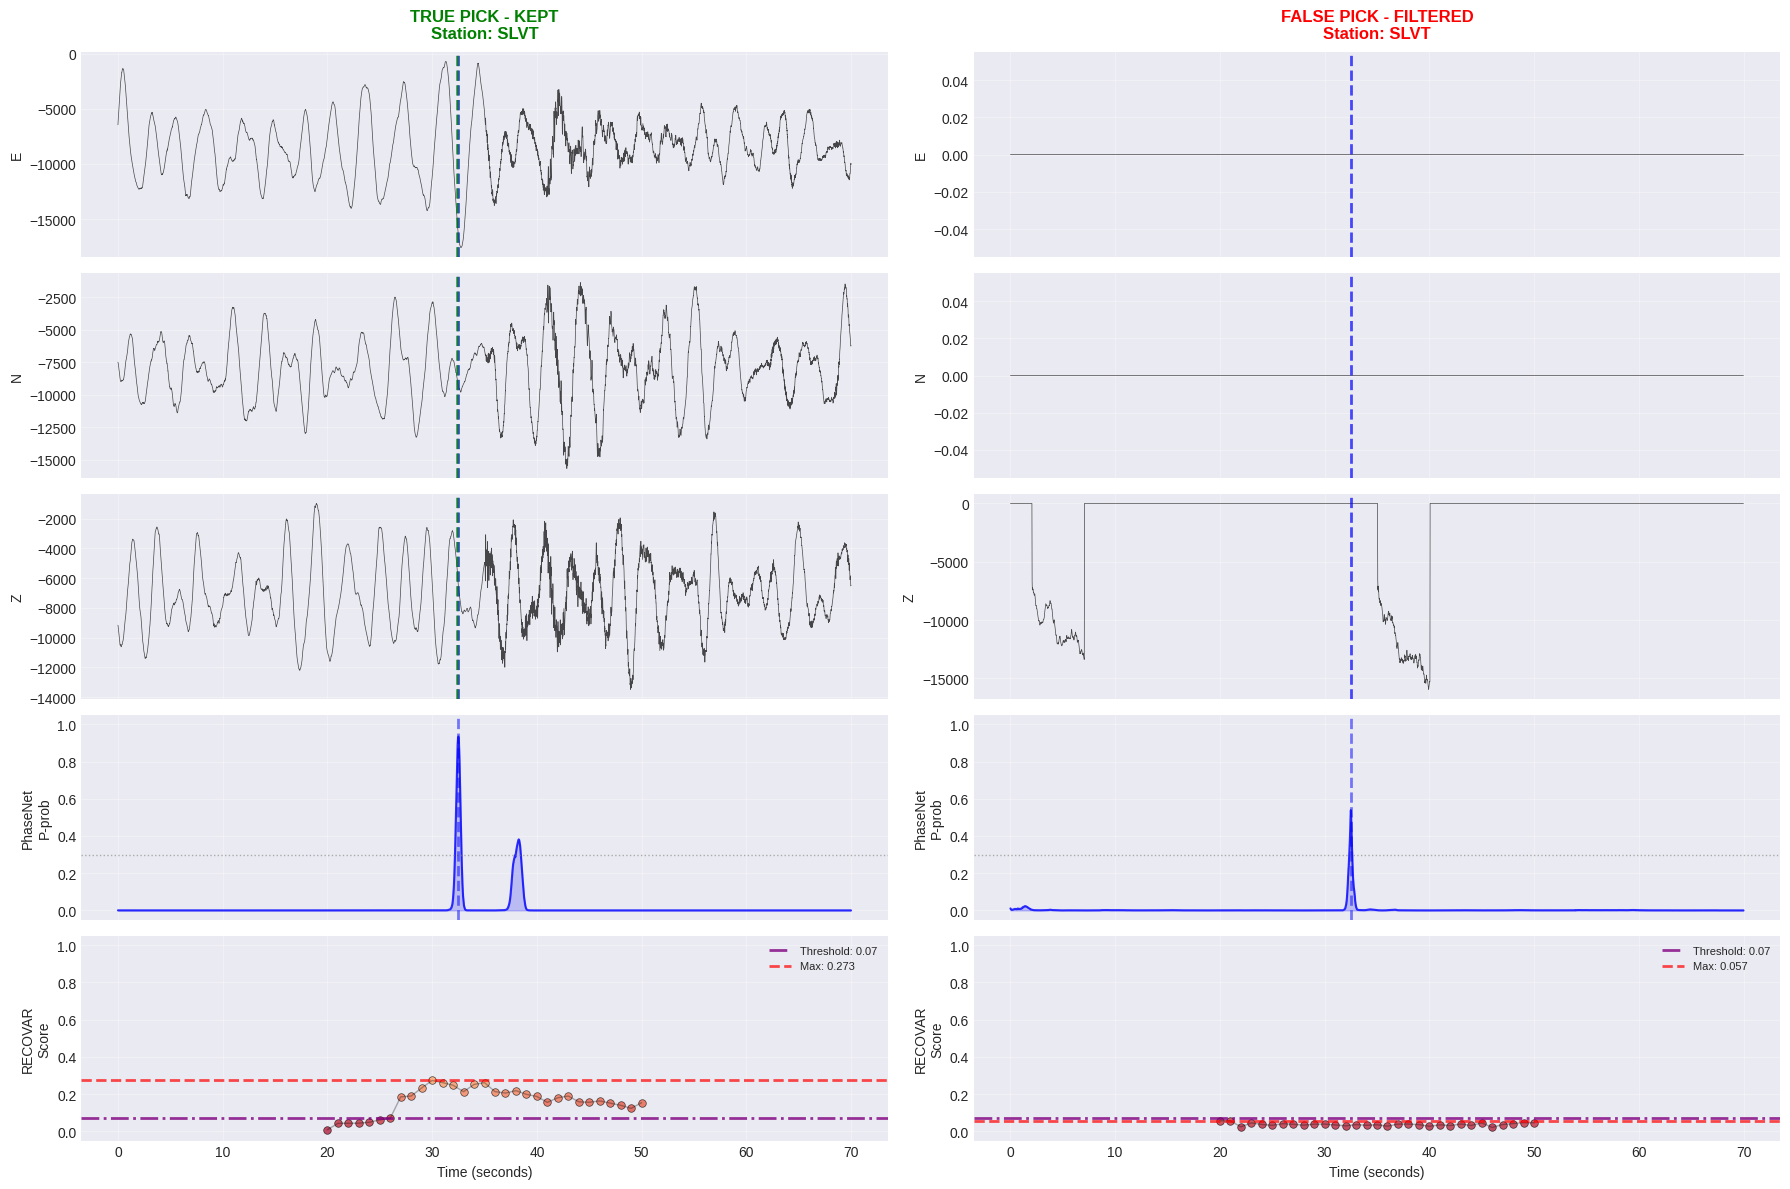

In [15]:
def plot_side_by_side_comparison(example1, result1, phasenet1, example2, result2, phasenet2, 
                                  threshold=0.07, score_type='max'):
    """
    Plot two examples side by side for comparison.
    """
    fig, axes = plt.subplots(5, 2, figsize=(18, 12), sharex='col')
    
    for col, (example, recovar_result, phasenet_result) in enumerate([(example1, result1, phasenet1), 
                                                                        (example2, result2, phasenet2)]):
        stream = example['stream']
        
        # Separate waveforms from annotations
        waveform_traces = [tr for tr in stream if not tr.stats.channel.endswith(('P', 'S', 'N')) or len(tr.stats.channel) > 1]
        z_trace = [tr for tr in waveform_traces if 'Z' in tr.stats.channel][0]
        n_trace = [tr for tr in waveform_traces if 'N' in tr.stats.channel or 'Y' in tr.stats.channel][0]
        e_trace = [tr for tr in waveform_traces if 'E' in tr.stats.channel or 'X' in tr.stats.channel][0]
        
        # Time arrays
        sampling_rate = z_trace.stats.sampling_rate
        times = np.arange(len(z_trace.data)) / sampling_rate
        
        # Calculate pick positions
        window_start = example['window_start']
        phasenet_pick = example['phasenet_pick']
        catalog_pick = example['catalog_pick']
        
        phasenet_pick_sec = (phasenet_pick - window_start).total_seconds()
        if catalog_pick:
            catalog_pick_sec = (catalog_pick - window_start).total_seconds()
        
        # Determine filtering decision
        score_value = recovar_result['max_score'] if score_type == 'max' else recovar_result['mean_score']
        is_kept = score_value >= threshold
        is_true_pick = catalog_pick is not None
        
        # Sliding window parameters
        window_size = 3000
        stride = 100
        trim_samples = 500
        
        # Calculate window centers
        n_windows = len(recovar_result['scores_array'])
        window_centers = [(i * stride + trim_samples + window_size // 2) / sampling_rate 
                         for i in range(n_windows)]
        scores = recovar_result['scores_array']
        
        # Plot waveforms
        for row, (trace, comp) in enumerate(zip([e_trace, n_trace, z_trace], ['E', 'N', 'Z'])):
            ax = axes[row, col]
            ax.plot(times, trace.data, 'k-', linewidth=0.5, alpha=0.7)
            ax.set_ylabel(f'{comp}', fontsize=10)
            ax.grid(True, alpha=0.3)
            
            # Mark picks
            ax.axvline(phasenet_pick_sec, color='blue', linestyle='--', 
                      linewidth=2, alpha=0.7)
            if catalog_pick:
                ax.axvline(catalog_pick_sec, color='green', linestyle='--', 
                          linewidth=2, alpha=0.7)
        
        # Plot PhaseNet probabilities
        ax_phasenet = axes[3, col]
        pn_times = phasenet_result['times']
        pn_probs = phasenet_result['p_prob']
        
        ax_phasenet.plot(pn_times, pn_probs, 'b-', linewidth=1.5, alpha=0.8)
        ax_phasenet.fill_between(pn_times, 0, pn_probs, color='blue', alpha=0.2)
        ax_phasenet.axhline(0.3, color='gray', linestyle=':', linewidth=1, alpha=0.6)
        ax_phasenet.axvline(phasenet_pick_sec, color='blue', linestyle='--', linewidth=2, alpha=0.5)
        
        ax_phasenet.set_ylabel('PhaseNet\nP-prob', fontsize=10)
        ax_phasenet.set_ylim(-0.05, 1.05)
        ax_phasenet.grid(True, alpha=0.3)
        
        # Plot RECOVAR scores
        ax_score = axes[4, col]
        colors = plt.cm.RdYlGn(scores)
        
        for i in range(len(window_centers)):
            ax_score.scatter(window_centers[i], scores[i], c=[colors[i]], 
                           s=30, alpha=0.7, edgecolors='black', linewidths=0.5)
        
        ax_score.plot(window_centers, scores, 'k-', linewidth=1, alpha=0.3)
        ax_score.axhline(threshold, color='purple', linestyle='-.', linewidth=2, 
                        label=f'Threshold: {threshold:.2f}', alpha=0.8)
        ax_score.axhline(score_value, color='red', linestyle='--', linewidth=2,
                        label=f'{score_type.title()}: {score_value:.3f}', alpha=0.7)
        
        ax_score.set_ylabel('RECOVAR\nScore', fontsize=10)
        ax_score.set_xlabel('Time (seconds)', fontsize=10)
        ax_score.set_ylim(-0.05, 1.05)
        ax_score.grid(True, alpha=0.3)
        ax_score.legend(loc='upper right', fontsize=8)
        
        # Column title
        pick_type = "TRUE PICK" if is_true_pick else "FALSE PICK"
        decision = "KEPT" if is_kept else "FILTERED"
        decision_color = 'green' if (is_true_pick and is_kept) or ( is_true_pick and not is_kept) else 'red'
        
        axes[0, col].set_title(f"{pick_type} - {decision}\nStation: {example['station']}", 
                              fontsize=12, fontweight='bold', color=decision_color, pad=10)
    
    plt.tight_layout()
    plt.show()

# Find examples of each category using the threshold of 0.07
RECOVAR_THRESHOLD = 0.07

# Categorize examples
tp_kept = []  # TRUE PICK kept by RECOVAR
tp_filtered = []  # TRUE PICK filtered by RECOVAR
fp_kept = []  # FALSE PICK kept by RECOVAR
fp_filtered = []  # FALSE PICK filtered by RECOVAR

for example in tp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    example['recovar_result'] = result
    example['phasenet_result'] = get_phasenet_probabilities(example['stream'])
    
    if result['max_score'] >= RECOVAR_THRESHOLD:
        tp_kept.append(example)
    else:
        tp_filtered.append(example)

for example in fp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    example['recovar_result'] = result
    example['phasenet_result'] = get_phasenet_probabilities(example['stream'])
    
    if result['max_score'] >= RECOVAR_THRESHOLD:
        fp_kept.append(example)
    else:
        fp_filtered.append(example)

print(f"TRUE PICKS kept by RECOVAR: {len(tp_kept)}")
print(f"TRUE PICKS filtered by RECOVAR: {len(tp_filtered)}")
print(f"FALSE PICKS kept by RECOVAR: {len(fp_kept)}")
print(f"FALSE PICKS filtered by RECOVAR: {len(fp_filtered)}")

# Plot comparisons
if tp_kept and fp_filtered:
    print("\n--- Comparison 1: Correct Decisions ---")
    plot_side_by_side_comparison(tp_kept[0], tp_kept[0]['recovar_result'], tp_kept[0]['phasenet_result'],
                                fp_filtered[0], fp_filtered[0]['recovar_result'], fp_filtered[0]['phasenet_result'],
                                threshold=RECOVAR_THRESHOLD)

if tp_filtered and fp_kept:
    print("\n--- Comparison 2: Incorrect Decisions ---")
    plot_side_by_side_comparison(tp_filtered[0] if tp_filtered else tp_kept[0], 
                                tp_filtered[0]['recovar_result'] if tp_filtered else tp_kept[0]['recovar_result'],
                                tp_filtered[0]['phasenet_result'] if tp_filtered else tp_kept[0]['phasenet_result'],
                                fp_kept[0], fp_kept[0]['recovar_result'], fp_kept[0]['phasenet_result'],
                                threshold=RECOVAR_THRESHOLD)

## Comparison: TRUE PICKS vs FALSE PICKS

Let's process multiple examples and compare the score distributions.

## Summary
- A well-chosen RECOVAR threshold can filter many false positives while retaining most true positives

For batch processing and full evaluation, see `run_yazel_batch_sliding.py`